<a href="https://colab.research.google.com/github/Adriandzidan/Tugas-Kecerdasan-Buatan/blob/main/Jobsheet7_EDA_ECommerc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
%matplotlib inline

## Data Wrangling

### Gathering Data
Digunakan beberapa tabel dari dataset Olist yang saling berelasi: `orders`, `order_items`, `products`, `product_category_name_translation`, dan `order_reviews`.

> Catatan untuk Google Colab: jalankan cell berikut untuk menghubungkan Google Drive dan menentukan lokasi folder data. Jika dataset Anda tersimpan di Google Drive, letakkan file CSV di folder `/content/drive/MyDrive/data/`.

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive terhubung.")
except Exception as e:
    print("Drive mount dilewati:", e)

data_dir = '/content/drive/MyDrive/data'
if not os.path.exists(data_dir):
    data_dir = 'data'

print("Menggunakan folder data:", data_dir)

In [ ]:
orders_path = os.path.join(data_dir, 'orders_dataset.csv')
order_items_path = os.path.join(data_dir, 'order_items_dataset.csv')
products_path = os.path.join(data_dir, 'products_dataset.csv')
category_translation_path = os.path.join(data_dir, 'product_category_name_translation.csv')
reviews_path = os.path.join(data_dir, 'order_reviews_dataset.csv')

for path in [orders_path, order_items_path, products_path, category_translation_path, reviews_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File tidak ditemukan: {path}")

orders_df = pd.read_csv(orders_path)
order_items_df = pd.read_csv(order_items_path)
products_df = pd.read_csv(products_path)
category_translation_df = pd.read_csv(category_translation_path)
reviews_df = pd.read_csv(reviews_path)

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Assessing Data

In [ ]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [ ]:
print("Missing value orders_df:")
print(orders_df.isna().sum())
print("\nMissing value order_items_df:")
print(order_items_df.isna().sum())
print("\nMissing value products_df:")
print(products_df.isna().sum())

Missing value orders_df:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing value order_items_df:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing value products_df:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [ ]:
print("Duplikat orders_df:", orders_df.duplicated().sum())
print("Duplikat order_items_df:", order_items_df.duplicated().sum())
print("Duplikat reviews_df:", reviews_df.duplicated().sum())

Duplikat orders_df: 0
Duplikat order_items_df: 0
Duplikat reviews_df: 0


### Cleaning Data

In [ ]:
# Konversi kolom tanggal ke datetime
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Hanya gunakan pesanan berstatus 'delivered' untuk analisis waktu pengiriman
orders_clean = orders_df[orders_df['order_status'] == 'delivered'].copy()
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])

# Hitung lama waktu pengiriman (hari) dan selisih terhadap estimasi
orders_clean['delivery_days'] = (orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']).dt.days
orders_clean['delay_days'] = (orders_clean['order_delivered_customer_date'] - orders_clean['order_estimated_delivery_date']).dt.days

orders_clean[['order_id', 'delivery_days', 'delay_days']].head()

,order_id,delivery_days,delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,8,-8
1,53cdb2fc8bc7dce0b6741e2150273451,13,-6
2,47770eb9100c2d0c44946d9cf07ec65d,9,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,13,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,2,-10


In [ ]:
# Gabungkan order_items dengan products & terjemahan kategori untuk analisis revenue per kategori
items_products = order_items_df.merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
items_products = items_products.merge(category_translation_df, on='product_category_name', how='left')
items_products['product_category_name_english'] = items_products['product_category_name_english'].fillna('unknown')

items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


**Insight Cleaning Data:**
- Analisis waktu pengiriman hanya menggunakan pesanan berstatus `delivered` dengan tanggal pengiriman lengkap, agar perhitungan `delivery_days` dan `delay_days` valid.
- Kategori produk yang tidak memiliki padanan nama bahasa Inggris diberi label `unknown` agar tidak hilang dari analisis.

## Exploratory Data Analysis (EDA)

### Explore Pertanyaan 1: Revenue per Kategori Produk & Tren Bulanan

In [ ]:
revenue_per_category = items_products.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)
revenue_per_category.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

In [ ]:
monthly_orders = orders_clean.set_index('order_purchase_timestamp').resample('ME')['order_id'].count()
monthly_orders.tail(10)

order_purchase_timestamp
2017-11-30    7288
2017-12-31    5513
2018-01-31    7069
2018-02-28    6555
2018-03-31    7003
2018-04-30    6798
2018-05-31    6749
2018-06-30    6096
2018-07-31    6156
2018-08-31    6351
Freq: ME, Name: order_id, dtype: int64

### Explore Pertanyaan 2: Review Score vs Lama & Keterlambatan Pengiriman

In [ ]:
orders_reviews = orders_clean.merge(reviews_df[['order_id', 'review_score']], on='order_id', how='inner')
review_delivery = orders_reviews.groupby('review_score')[['delivery_days', 'delay_days']].mean()
review_delivery

,delivery_days,delay_days
review_score,,
1,20.849973,-4.048060
2,16.194832,-8.634818
3,13.793242,-10.776912
4,11.848054,-12.380840
5,10.224154,-13.387599


## Visualization & Explanatory Analysis

### Pertanyaan 1: Top 10 Kategori Produk dengan Revenue Tertinggi & Tren Pesanan Bulanan

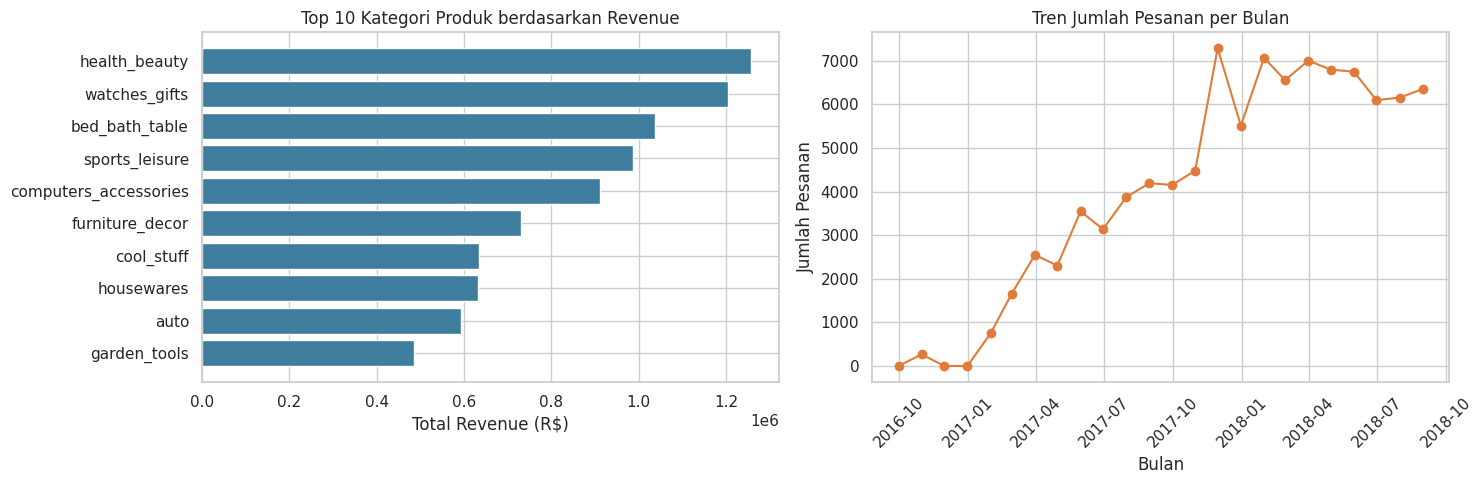

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top10 = revenue_per_category.head(10).sort_values()
axes[0].barh(top10.index, top10.values, color='#3f7d9e')
axes[0].set_title('Top 10 Kategori Produk berdasarkan Revenue')
axes[0].set_xlabel('Total Revenue (R$)')

axes[1].plot(monthly_orders.index, monthly_orders.values, marker='o', color='#e07b39')
axes[1].set_title('Tren Jumlah Pesanan per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Jumlah Pesanan')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Hubungan Review Score dengan Lama & Keterlambatan Pengiriman

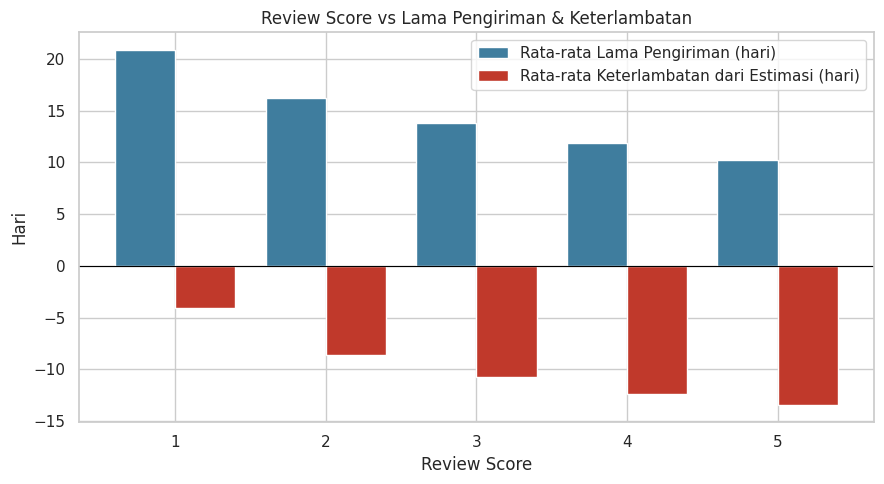

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 5))

x = review_delivery.index
ax1.bar(x - 0.2, review_delivery['delivery_days'], width=0.4, label='Rata-rata Lama Pengiriman (hari)', color='#3f7d9e')
ax1.bar(x + 0.2, review_delivery['delay_days'], width=0.4, label='Rata-rata Keterlambatan dari Estimasi (hari)', color='#c0392b')

ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Review Score')
ax1.set_ylabel('Hari')
ax1.set_title('Review Score vs Lama Pengiriman & Keterlambatan')
ax1.set_xticks(x)
ax1.legend()

plt.tight_layout()
plt.show()